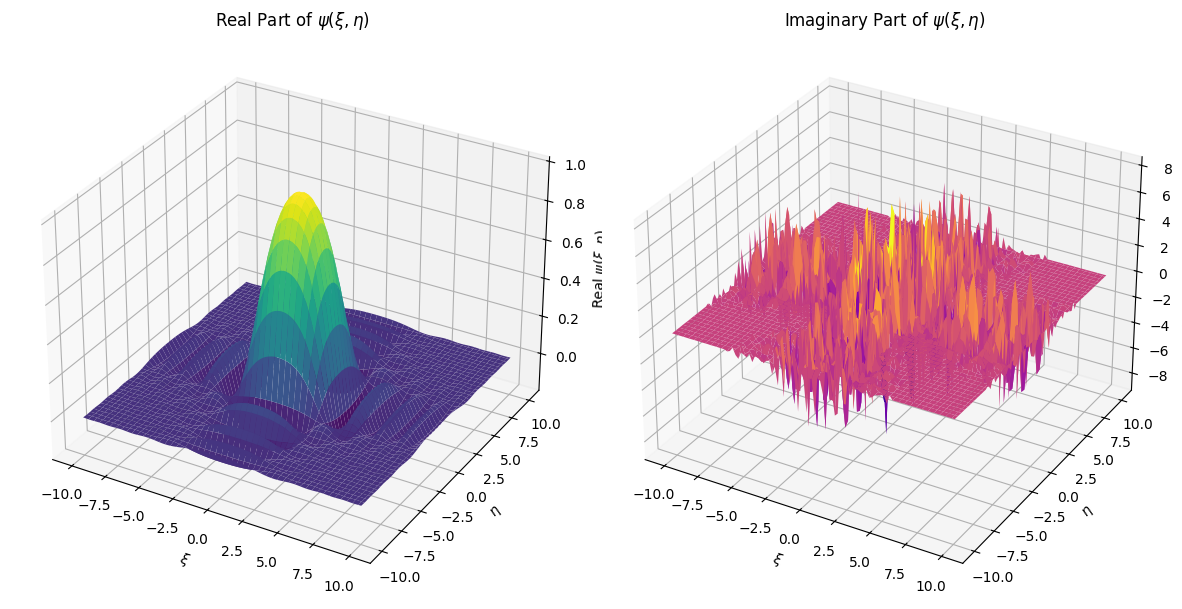

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import hyp1f1, exp
from mpl_toolkits.mplot3d import Axes3D

xi = np.linspace(-10, 10, 100)
eta = np.linspace(-10, 10, 100)
xi, eta = np.meshgrid(xi, eta)

hypergeom_1 = np.vectorize(lambda x: complex(hyp1f1(1 - 1j / 4, 2, -1j * x**2 / 2)))(xi)
hypergeom_2 = np.vectorize(lambda e: complex(hyp1f1(1 + 1j / 4, 2, 1j * e**2 / 2)))(eta)

complex_exponential = np.exp(1j * (xi**2 - eta**2) / 4)

wave_function = hypergeom_1 * hypergeom_2 * complex_exponential

wave_real = wave_function.real
wave_imag = wave_function.imag

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(xi, eta, wave_real, cmap='viridis')
ax.set_title(r'Real Part of $\psi(\xi, \eta)$')
ax.set_xlabel(r'$\xi$')
ax.set_ylabel(r'$\eta$')
ax.set_zlabel(r'Real $\psi(\xi, \eta)$')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(xi, eta, wave_imag, cmap='plasma')
ax2.set_title(r'Imaginary Part of $\psi(\xi, \eta)$')
ax2.set_xlabel(r'$\xi$')
ax2.set_ylabel(r'$\eta$')
ax2.set_zlabel(r'Imaginary $\psi(\xi, \eta)$')

plt.tight_layout()
plt.savefig("wave_function_3D.png", dpi=300)
plt.show()
